In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_path = "../data/raw/home_depot_data_1_2021_12.csv"

In [4]:
df = pd.read_csv(data_path)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2551 entries, 0 to 2550
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         2551 non-null   int64  
 1   url           2551 non-null   str    
 2   title         2551 non-null   str    
 3   images        2551 non-null   str    
 4   description   2551 non-null   str    
 5   product_id    2551 non-null   int64  
 6   sku           2407 non-null   float64
 7   gtin13        2170 non-null   float64
 8   brand         2551 non-null   str    
 9   price         2551 non-null   float64
 10  currency      2551 non-null   str    
 11  availability  2551 non-null   str    
 12  uniq_id       2551 non-null   str    
 13  scraped_at    2551 non-null   str    
dtypes: float64(3), int64(2), str(9)
memory usage: 279.1 KB


In [43]:
select_cols = ['title', 'description', 'brand']

In [44]:
df[select_cols].head(10)

,title,description,brand
0,Men's 3X Large Carbon Heather Cotton/Polyester...,"This heavyweight, water-repellent hooded sweat...",Carhartt
1,Turmode 30 ft. RP TNC Female to RP TNC Male Ad...,If you need more length between your existing ...,Unbranded
2,Large Tapestry Bolster Bed,Polyester cover resembling rich Italian tapest...,Carolina Pet Company
3,16-Gauge-Sinks Vessel Sink in White with Faucet,It features a rectangle shape. This vessel set...,Unbranded
4,Men's Crazy Horse 9'' Logger Boot - Steel Toe ...,This 9 in. black full grain leather logger boo...,Adtec
5,Mariana 6 ft. Multi-Color 3-Panel Screen Divider,With robust structure and sophisticated canvas...,HomeRoots
6,5 gal. #650C-2 Powdery Mist Semi-Gloss Interio...,BEHR PRO i300 Semi-Gloss Interior Paint has a ...,BEHR PRO
7,7/8 in. x 4-1/2 in. x 0.045 in. Metal and Stai...,DEWALT High Performance 0.045 in. Metal Cuttin...,DEWALT
8,Ring Gold Bar Cart,This Ring Bar Cart is sure to make a statement...,Titan Lighting
9,Traditional Silver Wooden Vanity Table,This transitional vanity table proudly display...,Benjara


In [45]:
df['combined_text'] = df['title'].astype(str) + ' ' + df['description'].astype(str)
df['title_len'] = df.title.str.len()
df['description_len'] = df.description.str.len()
df['combined_text_len'] = df.combined_text.str.len()

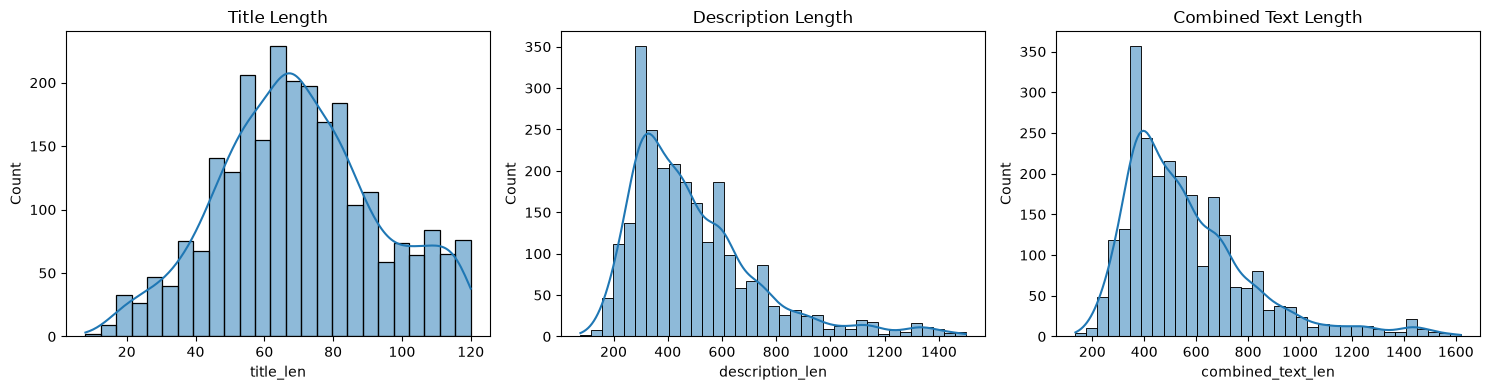

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(x='title_len', data=df, ax=axes[0], kde=True)
axes[0].set_title("Title Length")

sns.histplot(x='description_len', data=df, ax=axes[1], kde=True)
axes[1].set_title("Description Length")

sns.histplot(x='combined_text_len', data=df, ax=axes[2], kde=True)
axes[2].set_title("Combined Text Length")

plt.tight_layout()
plt.show()


## Preprocessing steps for keyword, semantic and hybrid search

### 1. Missing value analysis

In [49]:
# Check missing values
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])


Missing Values Summary:
        Missing Count  Percentage
gtin13            381   14.935319
sku               144    5.644845


### 2. Text quality and cleaning requirements

In [50]:
import re
from collections import Counter

# Sample text to check for special characters, HTML, etc.
sample_titles = df['title'].head(5)
sample_descriptions = df['description'].head(5)
sample_combined_text = df['combined_text'].head(5)

print("Sample text:")

for i, combined_text in enumerate(sample_combined_text, 1):
    print(f"  {i}. {combined_text[:80]}..." if len(combined_text) > 80 else f"  {i}. {combined_text}")

print("\nSpecial Characters Found:")
# Check for common issues
all_text = ' '.join(df['title'].astype(str)) + ' ' + ' '.join(df['description'].astype(str))
has_html = bool(re.search(r'<[^>]+>', all_text))
has_unicode = bool(re.search(r'[^\x00-\x7F]', all_text))
has_newlines = bool('\n' in all_text)
has_special = bool(re.search(r'[/+\-_@#$%^&*()[\]{};:\'",.<>?\\|`~]', all_text))

print(f"  HTML tags: {has_html}")
print(f"  Non-ASCII characters: {has_unicode}")
print(f"  Newlines/line breaks: {has_newlines}")
print(f"  Special characters (/, +, -, etc.): {has_special}")


Sample text:
  1. Men's 3X Large Carbon Heather Cotton/Polyester Rain Defender Paxton Heavyweight ...
  2. Turmode 30 ft. RP TNC Female to RP TNC Male Adapter Cable If you need more lengt...
  3. Large Tapestry Bolster Bed Polyester cover resembling rich Italian tapestries wr...
  4. 16-Gauge-Sinks Vessel Sink in White with Faucet It features a rectangle shape. T...
  5. Men's Crazy Horse 9'' Logger Boot - Steel Toe - Black Size 10.5(W) This 9 in. bl...

Special Characters Found:
  HTML tags: False
  Non-ASCII characters: True
  Newlines/line breaks: False
  Special characters (/, +, -, etc.): True


In [51]:
# Show which special characters are present
special_chars = re.findall(r'[/+\-_@#$%^&*()[\]{};:\'",.<>?\\|`~]', all_text)
if special_chars:
    print(f"\n  Special chars found: {set(special_chars)}")


  Special chars found: {'(', '-', ',', ';', '+', '#', '&', '"', ':', '%', '.', "'", '?', '*', ')', '/'}


In [52]:
# Find all non-ASCII characters in the dataset
non_ascii_chars = set()
for text in df['title']:
    for char in str(text):
        if ord(char) > 127:
            non_ascii_chars.add(char)
            
for text in df['description']:
    for char in str(text):
        if ord(char) > 127:
            non_ascii_chars.add(char)

if non_ascii_chars:
    print("Non-ASCII Characters Found:")
    for char in sorted(non_ascii_chars):
        print(f"  '{char}' (Unicode: U+{ord(char):04X})")
else:
    print("No non-ASCII characters found!")


Non-ASCII Characters Found:
  ' ' (Unicode: U+00A0)
  '¦' (Unicode: U+00A6)
  '®' (Unicode: U+00AE)
  '°' (Unicode: U+00B0)
  'µ' (Unicode: U+00B5)
  '¼' (Unicode: U+00BC)
  '½' (Unicode: U+00BD)
  'Ä' (Unicode: U+00C4)
  'Ø' (Unicode: U+00D8)
  'â' (Unicode: U+00E2)
  'é' (Unicode: U+00E9)
  'î' (Unicode: U+00EE)
  '​' (Unicode: U+200B)
  '–' (Unicode: U+2013)
  '—' (Unicode: U+2014)
  '‘' (Unicode: U+2018)
  '’' (Unicode: U+2019)
  '”' (Unicode: U+201D)
  '€' (Unicode: U+20AC)
  '™' (Unicode: U+2122)


### 3. Text tokenization and preprocessing (keyword search)

Analyzes vocabulary size, word frequency, and outlines tokenization strategy including stop word removal and stemming

In [53]:

# Analyze vocabulary size and word frequency
from collections import Counter

# Simple tokenization
def simple_tokenize(text):
    """Basic tokenization: lowercase and split on whitespace/punctuation"""
    text = str(text).lower()
    # Remove punctuation except hyphens in product names
    text = re.sub(r'[^a-z0-9\s-]', ' ', text)
    return text.split()

# Get vocabulary from both title and description
all_words = []
for title in df['title']:
    all_words.extend(simple_tokenize(title))
for description in df['description']:
    all_words.extend(simple_tokenize(description))

word_freq = Counter(all_words)
print(f"Vocabulary Size: {len(word_freq):,} unique words")
print(f"Total Tokens: {len(all_words):,}")
print(f"\nMost Common Words (from title + description):")
for word, count in word_freq.most_common(20):
    print(f"  '{word}': {count}")



Vocabulary Size: 13,139 unique words
Total Tokens: 234,998

Most Common Words (from title + description):
  'and': 8894
  'the': 6858
  'a': 5502
  'in': 5418
  'to': 4703
  'with': 3596
  'of': 3381
  'for': 3345
  'is': 2767
  'your': 2599
  'paint': 2120
  'this': 2032
  'that': 1661
  'you': 1408
  'x': 1387
  'are': 1366
  'or': 1349
  'on': 1261
  'primer': 1174
  'it': 1157


### 4. Semantic search preprocessing (embedding preparation)

In [54]:
# Analyze text length constraints for embeddings
print("Text Length Analysis for Embeddings:")
print(f"\nTitle Length:")
print(f"  Mean: {df['title_len'].mean():.1f} chars")
print(f"  Median: {df['title_len'].median():.1f} chars")
print(f"  Max: {df['title_len'].max():.1f} chars")
print(f"  Min: {df['title_len'].min():.1f} chars")

print(f"\nDescription Length:")
print(f"  Mean: {df['description_len'].mean():.1f} chars")
print(f"  Median: {df['description_len'].median():.1f} chars")
print(f"  Max: {df['description_len'].max():.1f} chars")
print(f"  Min: {df['description_len'].min():.1f} chars")

print(f"\nCombined text Length:")
print(f"  Mean: {df['combined_text_len'].mean():.1f} chars")
print(f"  Median: {df['combined_text_len'].median():.1f} chars")
print(f"  Max: {df['combined_text_len'].max():.1f} chars")
print(f"  Min: {df['combined_text_len'].min():.1f} chars")

# Check token count estimate (roughly 1 token per 4 chars)
df['title_tokens'] = df['title_len'] / 4
df['description_tokens'] = df['description_len'] / 4
df['combined_text_tokens'] = df['combined_text_len'] / 4

print(f"\nEstimated Token Count (title):")
print(f"  Mean: {df['title_tokens'].mean():.1f} tokens")
print(f"  Max: {df['title_tokens'].max():.1f} tokens")

print(f"\nEstimated Token Count (description):")
print(f"  Mean: {df['description_tokens'].mean():.1f} tokens")
print(f"  Max: {df['description_tokens'].max():.1f} tokens")

print(f"\nEstimated Token Count (combined text):")
print(f"  Mean: {df['combined_text_tokens'].mean():.1f} tokens")
print(f"  Max: {df['combined_text_tokens'].max():.1f} tokens")

print("\n✓ Semantic Search Preprocessing:")
print("  - Text cleaning (remove HTML, remove special chars, remove extra white space, and remove special characters i.e. accents, emojis)")
print("  - Normalize(lowercase)")
print("  - Truncate very long texts (OpenAI has token limits: ~8k tokens)")
print("  - Combine fields strategically:")
print("    - Option A: Use title + description as combined text")
print("    - Option B: Embed title and description separately")
print("  - Generate embeddings using OpenAI API or Hugging Face models")
print("  - Store embeddings in Weaviate vector DB")


Text Length Analysis for Embeddings:

Title Length:
  Mean: 70.1 chars
  Median: 69.0 chars
  Max: 120.0 chars
  Min: 8.0 chars

Description Length:
  Mean: 495.0 chars
  Median: 436.0 chars
  Max: 1499.0 chars
  Min: 78.0 chars

Combined text Length:
  Mean: 566.1 chars
  Median: 505.0 chars
  Max: 1619.0 chars
  Min: 135.0 chars

Estimated Token Count (title):
  Mean: 17.5 tokens
  Max: 30.0 tokens

Estimated Token Count (description):
  Mean: 123.8 tokens
  Max: 374.8 tokens

Estimated Token Count (combined text):
  Mean: 141.5 tokens
  Max: 404.8 tokens

✓ Semantic Search Preprocessing:
  - Text cleaning (remove HTML, remove special chars, remove extra white space, and remove special characters i.e. accents, emojis)
  - Normalize(lowercase)
  - Truncate very long texts (OpenAI has token limits: ~8k tokens)
  - Combine fields strategically:
    - Option A: Use title + description as combined text
    - Option B: Embed title and description separately
  - Generate embeddings using Op

### 6. Hybrid Search Combined Strategy

In [55]:
print("HYBRID SEARCH PREPROCESSING CHECKLIST:")
print("\n📋 Data Cleaning:")
print("  ☐ Remove or fill missing values")
print("  ☐ Remove HTML tags from descriptions")
print("  ☐ Normalize Unicode and special characters")
print("  ☐ Remove extra whitespace and line breaks")

print("\n🔤 Keyword Search Preparation:")
print("  ☐ Lowercase normalization")
print("  ☐ Tokenization")
print("  ☐ Stop word removal (e.g., 'the', 'a', 'in')")
print("  ☐ Stemming/Lemmatization")
print("  ☐ Build inverted index")
print("  ☐ Store indexed data in searchable format")

print("\n🧠 Semantic Search Preparation:")
print("  ☐ Create text snippets (combine title + description)")
print("  ☐ Truncate texts to token limits (~8k)")
print("  ☐ Generate embeddings via OpenAI API or Hugging Face models")
print("  ☐ Store embeddings in Weaviate vector database")
print("  ☐ Maintain metadata (title, description, URL, price, etc.)")

print("\n⚙️ Hybrid Search Integration:")
print("  ☐ Combine keyword scores + semantic similarity scores")
print("  ☐ Normalize scores to 0-1 range")
print("  ☐ Apply weighted averaging (e.g., 60% keyword, 40% semantic)")
print("  ☐ Support filtering by brand, price, availability")
print("  ☐ Re-rank results by relevance")

print("\n📊 Dataset Statistics Summary:")
print(f"  Total Products: {len(df):,}")
print(f"  Avg Title Length: {df['title_len'].mean():.0f} characters")
print(f"  Avg Description Length: {df['description_len'].mean():.0f} characters")
print(f"  Avg Combined Text Length: {df['combined_text_len'].mean():.0f} characters")
print(f"  Unique Brands: {df['brand'].nunique():,}")


HYBRID SEARCH PREPROCESSING CHECKLIST:

📋 Data Cleaning:
  ☐ Remove or fill missing values
  ☐ Remove HTML tags from descriptions
  ☐ Normalize Unicode and special characters
  ☐ Remove extra whitespace and line breaks

🔤 Keyword Search Preparation:
  ☐ Lowercase normalization
  ☐ Tokenization
  ☐ Stop word removal (e.g., 'the', 'a', 'in')
  ☐ Stemming/Lemmatization
  ☐ Build inverted index
  ☐ Store indexed data in searchable format

🧠 Semantic Search Preparation:
  ☐ Create text snippets (combine title + description)
  ☐ Truncate texts to token limits (~8k)
  ☐ Generate embeddings via OpenAI API or Hugging Face models
  ☐ Store embeddings in Weaviate vector database
  ☐ Maintain metadata (title, description, URL, price, etc.)

⚙️ Hybrid Search Integration:
  ☐ Combine keyword scores + semantic similarity scores
  ☐ Normalize scores to 0-1 range
  ☐ Apply weighted averaging (e.g., 60% keyword, 40% semantic)
  ☐ Support filtering by brand, price, availability
  ☐ Re-rank results by rel